# Matplotlib Cheat Sheet

A brief matplotlib reference for the most common plot types.
---

**Contents**
1. [`plot` — Line & marker plots](#plot)
2. [`scatter` — Scatter plots](#scatter)
3. [`hist` — Histograms](#hist)
4. [`bar` — Vertical bar charts](#bar)
5. [`barh` — Horizontal bar charts](#barh)
6. [Axes & Figure properties](#axes-figure)

In [1]:
import matplotlib.pyplot as plt
import numpy as np

<a id='plot'></a>
---
## 1. `plt.plot` — Line & Marker Plots

**Signature**
```python
plt.plot([x], y, [fmt], *, data=None, **kwargs)
```

The workhorse function. Draws connected lines, markers, or both. You can pass multiple `(x, y)` or `(x, y, fmt)` triples in a single call to plot several series at once.

---

### Positional arguments

| Argument | Type | Description |
|---|---|---|
| `x` | array-like *(optional)* | X coordinates. Defaults to `[0, 1, 2, …]` if omitted. |
| `y` | array-like | Y coordinates. **Required.** |
| `fmt` | str *(optional)* | Shorthand format string combining color, marker, and linestyle (see below). |

---

### The format string `fmt`

Pattern: **`[color][marker][linestyle]`** — all three parts are optional and can appear in any order.

**Colors** — single letter: `b` blue · `g` green · `r` red · `c` cyan · `m` magenta · `y` yellow · `k` black · `w` white

**Markers**

| Code | Shape | Code | Shape |
|---|---|---|---|
| `.` | point | `o` | circle |
| `s` | square | `^` | triangle up |
| `v` | triangle down | `D` | diamond |
| `+` | plus | `x` | cross |
| `*` | star | `p` | pentagon |

**Linestyles**

| Code | Style |
|---|---|
| `-` | solid |
| `--` | dashed |
| `-.` | dash-dot |
| `:` | dotted |
| *(none)* | no line (markers only) |

```python
plt.plot(x, y, 'r--')    # red dashed line, no markers
plt.plot(x, y, 'go')     # green circles, no line
plt.plot(x, y, 'b.-')    # blue solid line with point markers
```

---

### Key keyword arguments

| Parameter | Default | Description |
|---|---|---|
| `color` / `c` | auto-cycle | Line color. Accepts any matplotlib color spec: `'red'`, `'#FF5733'`, `(0.1, 0.9, 0.5)`, etc. |
| `linewidth` / `lw` | `1.5` | Line thickness in points. |
| `linestyle` / `ls` | `'-'` | `'solid'`, `'dashed'`, `'dashdot'`, `'dotted'`, or a dash tuple `(offset, (on, off, …))`. |
| `marker` | `None` | Marker style, e.g. `'o'`, `'s'`, `'^'`. |
| `markersize` / `ms` | `6` | Marker diameter in points. |
| `markerfacecolor` / `mfc` | same as color | Fill color of markers. Use `'none'` for hollow markers. |
| `markeredgecolor` / `mec` | auto | Edge color of markers. |
| `alpha` | `1.0` | Opacity (0 = transparent, 1 = opaque). |
| `label` | `None` | Label shown in the legend when `ax.legend()` is called. |
| `zorder` | auto | Drawing order — higher values draw on top. |

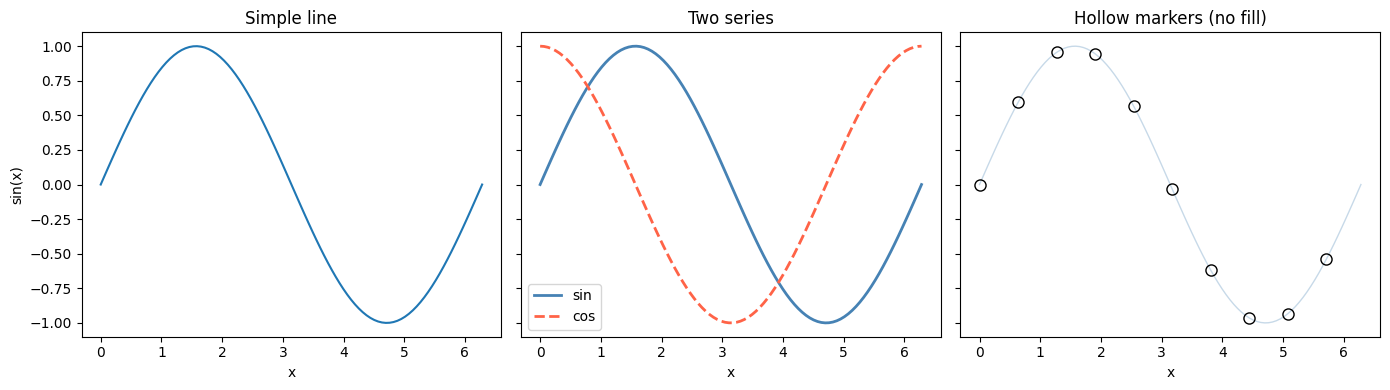

In [ ]:
# --- plot: minimal examples ---
x = np.linspace(0, 2 * np.pi, 100)

fig, axes = plt.subplots(1, 3, 
                         figsize=(14, 4), 
                         sharey = True) # Makes it that the three plots share the same y-axis

# 1) Simple line
axes[0].plot(x, np.sin(x))
axes[0].set(
    title = 'Simple line',
    xlabel = 'x',
    ylabel = 'sin(x)',
)

# 2) Two series with custom styles
axes[1].plot(x, np.sin(x), label='sin', color='steelblue', lw=2)
axes[1].plot(x, np.cos(x), label='cos', color='tomato', lw=2, ls='--')
axes[1].legend()
axes[1].set(
    title = 'Two series',
    xlabel = 'x',
)

# 3) Markers only (no line) via fmt string
axes[2].plot(x, np.sin(x), lw=1, color='steelblue', alpha=0.3)          # faint guide line
axes[2].plot(x[::10], np.sin(x[::10]), 'ko', markersize=8, mfc='none')  # hollow markers
axes[2].set(
    title = 'Hollow markers (no fill)',
    xlabel = 'x',
)

fig.tight_layout()
plt.show()

<a id='scatter'></a>
---
## 2. `plt.scatter` — Scatter Plots

**Signature**
```python
plt.scatter(x, y, s=None, c=None, marker=None, cmap=None,
            norm=None, vmin=None, vmax=None, alpha=None,
            linewidths=None, edgecolors=None, plotnonfinite=False,
            **kwargs)
```

Like `plot`, but each point is drawn independently, which lets you vary size and color per point. Use `plot` for speed when you don't need per-point styling; use `scatter` when you do.

---

### Parameters

| Parameter | Default | Description |
|---|---|---|
| `x`, `y` | — | 1-D arrays of point coordinates. **Required.** |
| `s` | `rcParams['lines.markersize'] ** 2` | Marker area in **points²** (not diameter!). Can be a scalar (all same size) or an array (one value per point). |
| `c` | `None` | Marker color(s). Accepts: a single color string, a sequence of colors, or a numeric array used with `cmap`. When `c` is a numeric array the colorbar encodes the third variable. |
| `marker` | `'o'` | Marker style — same codes as `plot`. |
| `cmap` | `rcParams['image.cmap']` | Colormap applied when `c` is numeric, e.g. `'viridis'`, `'plasma'`, `'RdYlGn'`. |
| `norm` | `None` | Normalization for `c` mapping. Use `plt.Normalize(vmin, vmax)` to set explicit bounds. |
| `vmin`, `vmax` | `None` | Shorthand for clipping the colormap range without creating a `Normalize` object. Ignored if `norm` is set. |
| `alpha` | `None` | Opacity, 0–1. Useful for dense clouds of points. |
| `linewidths` | `1.5` | Width of the marker edge(s). |
| `edgecolors` | `'face'` | Edge color. `'face'` = same as fill, `'none'` = no edge, or a color/array. |
| `plotnonfinite` | `False` | If `True`, plot points with `inf` or `nan` in `c` using the colormap's bad-value color. |

**Return value:** a `PathCollection` object (useful for attaching a colorbar: `plt.colorbar(sc)`).

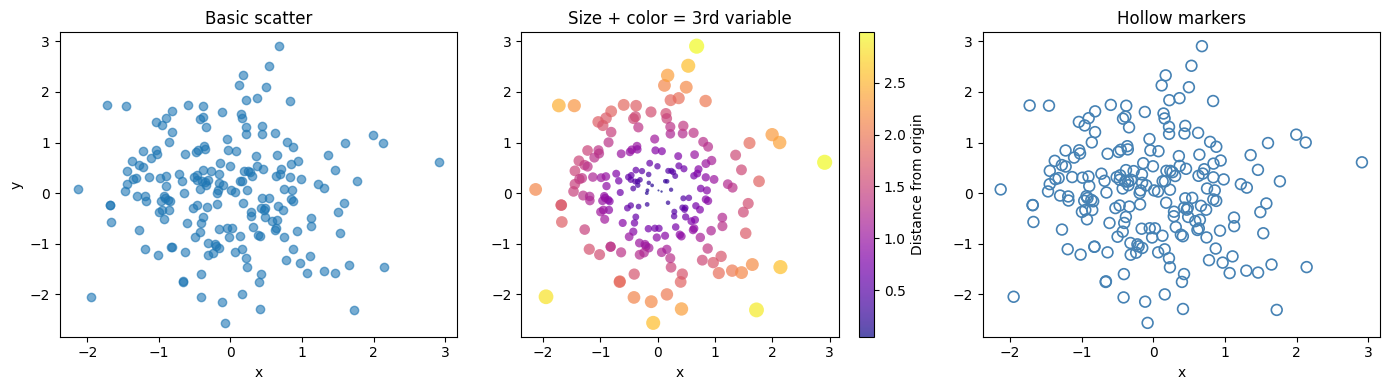

In [ ]:
# --- scatter: minimal examples ---
rng = np.random.default_rng(42)
x, y = rng.standard_normal((2, 200))
z = np.hypot(x, y)   # distance from origin — used as a third variable

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1) Basic scatter
axes[0].scatter(x, y, alpha=0.6)
axes[0].set(
    title = 'Basic scatter',
    xlabel = 'x',
    ylabel = 'y',
)

# 2) Size and color both encode a third variable
sc = axes[1].scatter(x, y, s=z * 40, c=z, cmap='plasma', alpha=0.7, edgecolors='none')
fig.colorbar(sc, ax=axes[1], label='Distance from origin')
axes[1].set(
    title = 'Size + color = 3rd variable',
    xlabel = 'x',
)

# 3) Hollow markers
axes[2].scatter(x, y, s=60, facecolors='none', edgecolors='steelblue', linewidths=1.2)
axes[2].set(
    title ='Hollow markers',
    xlabel = 'x',
})

fig.tight_layout()
plt.show()

<a id='hist'></a>
---
## 3. `plt.hist` — Histograms

**Signature**
```python
plt.hist(x, bins=None, *, range=None, density=False, weights=None,
         cumulative=False, bottom=None, histtype='bar', align='mid',
         orientation='vertical', rwidth=None, log=False, color=None,
         label=None, stacked=False, **kwargs)
```

Computes a histogram (via `numpy.histogram`) and draws it. `x` can be a single array, a list of arrays (for multiple overlaid distributions), or a 2-D array where each column is treated as a separate dataset.

> **Tip for large datasets (> 1 000 bins):** pre-bin with `np.histogram` and render with `plt.stairs()` for much faster drawing.

---

### Parameters

| Parameter | Default | Description |
|---|---|---|
| `x` | — | Input data. Single array or list of arrays. **Required.** |
| `bins` | `None` (→ 10) | Number of equal-width bins (int), explicit bin edges (array), or a string strategy: `'auto'`, `'fd'`, `'doane'`, `'scott'`, `'stone'`, `'rice'`, `'sturges'`, `'sqrt'`. |
| `range` | *(min, max) of data* | Tuple `(lower, upper)` — values outside are ignored. |
| `density` | `False` | If `True`, normalize so the total area equals 1 (probability density). |
| `weights` | `None` | Array of weights, same shape as `x`. Each value contributes its weight to its bin. |
| `cumulative` | `False` | If `True`, each bin is the count of all data up to and including that bin. Pass `-1` for a reversed cumulative histogram. |
| `histtype` | `'bar'` | `'bar'` — traditional side-by-side bars · `'barstacked'` — stacked bars · `'step'` — unfilled step line · `'stepfilled'` — filled step line (faster for large n). |
| `align` | `'mid'` | Position of bars relative to bin edges: `'left'`, `'mid'`, `'right'`. |
| `orientation` | `'vertical'` | `'vertical'` for bars rising upward; `'horizontal'` for bars extending rightward. |
| `rwidth` | `None` | Relative width of each bar as a fraction of the bin width (0–1). `None` = use full width. |
| `log` | `False` | Use a log scale on the count axis. |
| `color` | `None` | Color(s) for the bars. One color per dataset if `x` is a list. |
| `label` | `None` | Label(s) for the legend. |
| `stacked` | `False` | If `True`, multiple datasets are stacked on top of each other (requires multiple inputs). |

**Return values:** `(n, bins, patches)` — counts (or densities), bin edges, and the patch objects (useful for custom coloring).

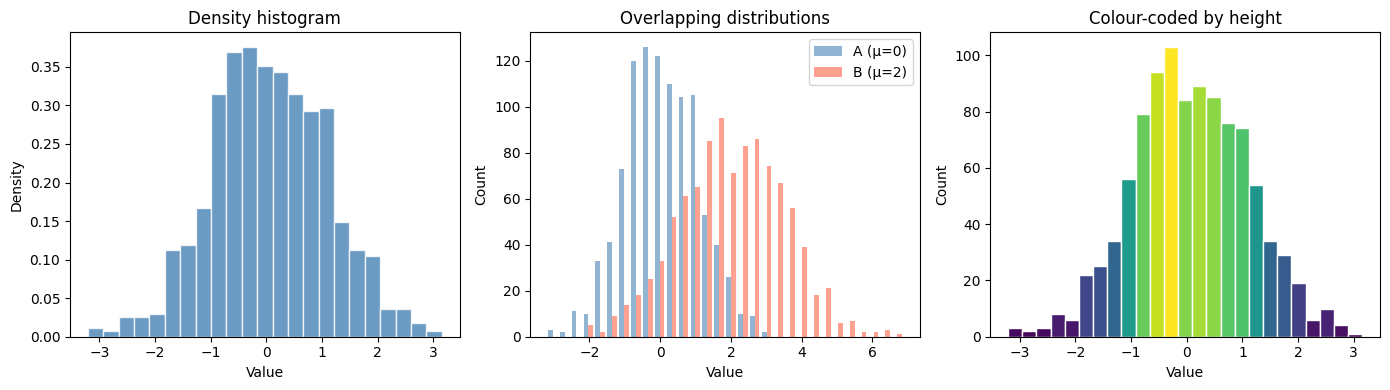

In [ ]:
data  = np.random.randn(1000)
data2 = 1.5*np.random.randn(1000)+2

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1) Density histogram with styled bars
axes[0].hist(data, bins='auto', density=True, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set(
    title =  'Density histogram',
    xlabel =  'Value',
    ylabel =  'Density',
)

# 2) Two overlapping distributions
axes[1].hist([data, data2], bins=30, alpha=0.6,
             label=['A (mean=0)', 'B (mean=2)'],
             color=['steelblue', 'tomato'])
axes[1].legend()
axes[1].set(
    title =  'Overlapping distributions',
    xlabel =  'Value',
    ylabel =  'Count',
)

# 3) Colour patches by bar height
n, bins, patches = axes[2].hist(data, bins=25, edgecolor='white')
for patch, height in zip(patches, n):
    patch.set_facecolor(plt.cm.viridis(height / n.max()))
axes[2].set(
    title =  'Colour-coded by height',
    xlabel =  'Value',
    ylabel =  'Count',
)

fig.tight_layout()
plt.show()

<a id='bar'></a>
---
## 4. `plt.bar` — Vertical Bar Charts

**Signature**
```python
plt.bar(x, height, width=0.8, bottom=None, *, align='center',
        data=None, **kwargs)
```

Draws vertical bars. Each bar is centered (or edge-aligned) on its `x` position. Most parameters accept either a single value (applied to all bars) or an array (one value per bar).

---

### Parameters

| Parameter | Default | Description |
|---|---|---|
| `x` | — | X positions of the bars. Can be numbers or strings (auto-creates categorical axis). **Required.** |
| `height` | — | Heights of the bars. **Required.** |
| `width` | `0.8` | Bar width(s) in data units. |
| `bottom` | `0` | Y coordinate(s) of the bar bases. Pass the heights of a previous bar series to create **stacked bar charts**. |
| `align` | `'center'` | Whether `x` marks the bar center (`'center'`) or left edge (`'edge'`). |
| `color` | auto-cycle | Face color(s). |
| `edgecolor` / `ec` | `None` | Edge color(s). |
| `linewidth` / `lw` | `None` | Edge line width. `0` removes the edge entirely. |
| `tick_label` | `None` | Custom tick labels beneath each bar (list of strings). |
| `label` | `None` | Single label for the whole series in the legend, **or** a list to label individual bars (useful with varied colors). |
| `xerr`, `yerr` | `None` | Error bar sizes. Accepts a scalar, 1-D array (symmetric), or `(2, N)` array (asymmetric, row 0 = lower, row 1 = upper). |
| `error_kw` | `{}` | Dict of kwargs forwarded to `errorbar` for styling error bars (e.g. `{'ecolor': 'black', 'capsize': 4}`). |
| `capsize` | `0` | Length of the error bar caps in points. |
| `log` | `False` | Log scale on the Y axis. |
| `alpha` | `1.0` | Opacity. |

**Return value:** a `BarContainer` (iterable of `Rectangle` patches).

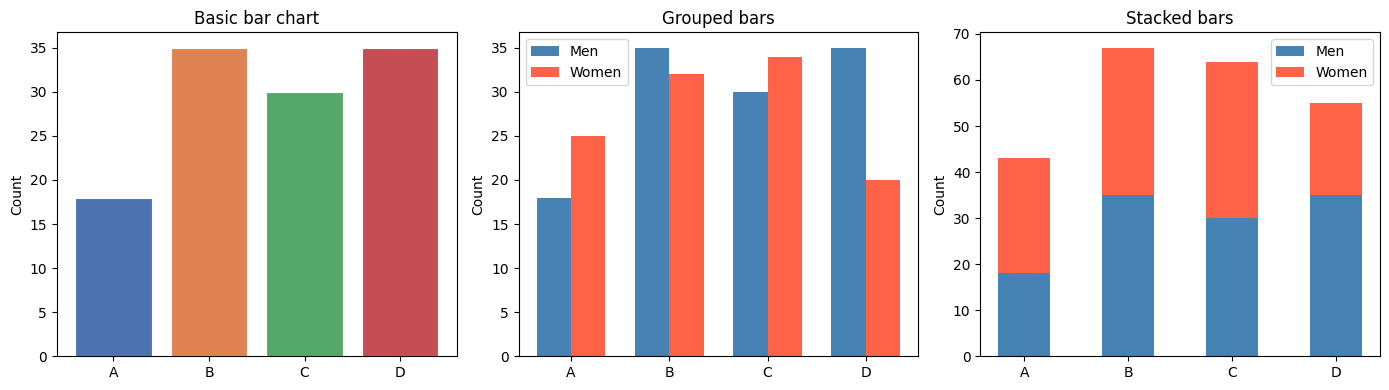

In [12]:
# --- bar: minimal examples ---
categories = ['A', 'B', 'C', 'D']
men   = [18, 35, 30, 35]
women = [25, 32, 34, 20]
x = np.arange(len(categories))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1) Basic with per-bar colours
axes[0].bar(categories, men,
            color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'],
            edgecolor='white', linewidth=0.8)
axes[0].set(
    title = 'Basic bar chart',
    ylabel = 'Count',
)

# 2) Grouped bars
w = 0.35
axes[1].bar(x - w/2, men,   width=w, label='Men',   color='steelblue')
axes[1].bar(x + w/2, women, width=w, label='Women', color='tomato')
axes[1].set(
    title = 'Grouped bars',
    xticks = x,
    xticklabels = categories,
    ylabel = 'Count',
)
axes[1].legend()

# 3) Stacked bars
axes[2].bar(categories, men,   label='Men',   color='steelblue', width=0.5)
axes[2].bar(categories, women, label='Women', color='tomato',    width=0.5, bottom=men)
axes[2].set(
    title = 'Stacked bars',
    ylabel = 'Count',
)
axes[2].legend()

fig.tight_layout()
plt.show()

<a id='barh'></a>
---
## 5. `plt.barh` — Horizontal Bar Charts

**Signature**
```python
plt.barh(y, width, height=0.8, left=None, *, align='center',
         data=None, **kwargs)
```

The horizontal counterpart of `bar`. Bars extend rightward from `left` by `width`. Roles of the axes are swapped: `y` is the categorical/positional axis and `width` is the value axis. Everything that applies to `bar` applies here — just mentally swap X ↔ Y.

---

### Parameters

| Parameter | Default | Description |
|---|---|---|
| `y` | — | Y positions of the bars. Numbers or strings. **Required.** |
| `width` | — | Bar lengths (the values being plotted). **Required.** |
| `height` | `0.8` | Bar thickness in data units *(equivalent to `width` in `bar`)*. |
| `left` | `0` | X coordinate(s) of the bar left edges *(equivalent to `bottom` in `bar`)*. Use for stacked horizontal bars. |
| `align` | `'center'` | Whether `y` marks the bar center (`'center'`) or bottom edge (`'edge'`). |
| `color` | auto-cycle | Face color(s). |
| `edgecolor` / `ec` | `None` | Edge color(s). |
| `linewidth` / `lw` | `None` | Edge line width. |
| `tick_label` | `None` | Custom tick labels alongside each bar. |
| `label` | `None` | Legend label(s). |
| `xerr`, `yerr` | `None` | Error bar sizes (same format as `bar`). `xerr` is most common here. |
| `error_kw` | `{}` | Style kwargs for error bars. |
| `capsize` | `0` | Length of error bar caps. |
| `log` | `False` | Log scale on the X (value) axis. |
| `alpha` | `1.0` | Opacity. |

**Return value:** a `BarContainer`.

> **Tip:** call `ax.invert_yaxis()` after `barh` when using string labels so the first item appears at the top.

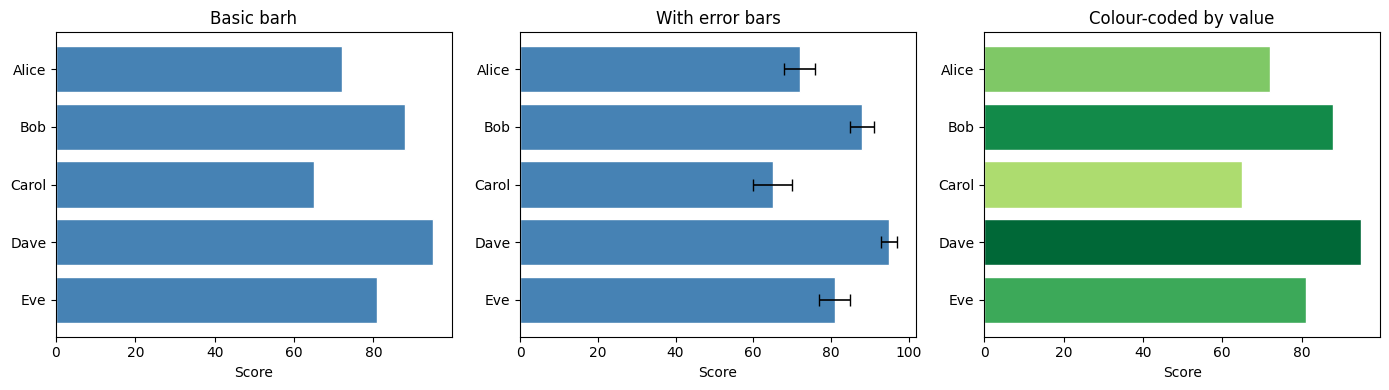

In [ ]:
# barh Example

people = ['Alice', 'Bob', 'Carol', 'Dave', 'Eve']
scores = [72, 88, 65, 95, 81]
errors = [4, 3, 5, 2, 4]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1) Basic + invert so first name is on top
axes[0].barh(people, scores, color='steelblue', edgecolor='white')
axes[0].invert_yaxis()
axes[0].set(
    title = 'Basic barh',
    xlabel = 'Score',
)

# 2) With error bars
axes[1].barh(people, scores, xerr=errors, capsize=4,
             color='steelblue', edgecolor='white',
             error_kw={'ecolor': 'black', 'linewidth': 1.2})
axes[1].invert_yaxis()
axes[1].set(
    title = 'With error bars',
    xlabel = 'Score',
)

# 3) Colour-code bars by value using a colormap
colors = plt.cm.RdYlGn([s / max(scores) for s in scores])
axes[2].barh(people, scores, color=colors, edgecolor='white')
axes[2].invert_yaxis()
axes[2].set(
    title = 'Colour-coded by value',
    xlabel = 'Score',
)

fig.tight_layout()
plt.show()

<a id='axes-figure'></a>
---
## 6. Axes & Figure Properties

Most customization lives on the **`Axes`** object (`ax`) returned by `plt.subplots()`. A few things (e.g. size, DPI, spacing, and background color) belong to the **`Figure`** object (`fig`).

### The `ax.set()` shortcut

If you are wanting to change just one attribute at a time, you may use the underscore (_) shortcut notation instead of the `ax.set()`.  What is the underscore notation? I'll demonstrate with an example:

```python
ax.set(
    title = 'Monthly Sales',
    ylabel = 'Sales ($)'
)
```

is equivalent to:

```python
ax.set_title('Monthly Sales')
ax.set_ylabel('Sales ($)')
```

`ax.set_title()`, `ax.set_xlabel()`, etc. one at a time, you can set many properties at once with a single `ax.set(**{...})` call. Any keyword accepted by `ax.set_<property>()` works as a key:

```python
ax.set(**{
    'title':       'My Plot',
    'xlabel':      'Time (s)',
    'ylabel':      'Amplitude',
    'xlim':        (0, 10),
    'ylim':        (-1.5, 1.5),
    'xscale':      'linear',
    'yscale':      'linear',
    'facecolor':   '#f7f7f7',   # axes background colour
    'aspect':      'auto',
})
```

---

### 6.1 Figure-level settings

```python
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
```

| Method / Argument | Description |
|---|---|
| `figsize=(w, h)` | Figure width × height in **inches**. |
| `dpi=150` | Dots per inch — higher = sharper. Default: 100. |
| `fig.set_size_inches(w, h)` | Resize after creation. |
| `fig.patch.set_facecolor('#eef2f7')` | **Figure background color.** `fig.patch` is the `Rectangle` that fills the whole canvas outside and between subplots. |
| `fig.patch.set_alpha(0.0)` | Make the figure background transparent (combine with `savefig(..., transparent=True)`). |
| `fig.suptitle('text', fontsize=14, y=1.02)` | Super-title centered above all subplots. |
| `fig.tight_layout()` | Auto-adjust padding so labels don't overlap. Call **after** all axes are set up. |
| `fig.subplots_adjust(left, right, bottom, top, wspace, hspace)` | Manual subplot spacing (values 0–1 as fractions of figure size). |
| `fig.savefig('file.png', dpi=200, bbox_inches='tight', transparent=False)` | Save to disk. Formats: `png`, `pdf`, `svg`, `eps`. |

---

### 6.2 `ax.set()` property reference

| Key | Example value | Description |
|---|---|---|
| `'title'` | `'My chart'` | Axes title. |
| `'xlabel'` | `'Time (s)'` | X-axis label. |
| `'ylabel'` | `'Amplitude'` | Y-axis label. |
| `'xlim'` | `(0, 10)` | X-axis range. |
| `'ylim'` | `(-1, 1)` | Y-axis range. |
| `'xscale'` | `'log'` | X-axis scale: `'linear'`, `'log'`, `'symlog'`, `'logit'`. |
| `'yscale'` | `'log'` | Y-axis scale. |
| `'xticks'` | `[0, 1, 2, 3]` | Tick positions on X axis. |
| `'yticks'` | `[0, 0.5, 1]` | Tick positions on Y axis. |
| `'xticklabels'` | `['a','b','c']` | Custom X tick labels (pair with `'xticks'`). |
| `'yticklabels'` | `['low','high']` | Custom Y tick labels. |
| `'facecolor'` | `'#f0f4f8'` | **Axes background color** — the plot area inside the spines. Also settable as `ax.set_facecolor(color)`. |
| `'aspect'` | `'equal'` | Data aspect ratio: `'equal'`, `'auto'`, or a float. |

---

### 6.3 Axes — grid, spines & legend

| Method | Description |
|---|---|
| `ax.grid(True, axis='both', linestyle='--', linewidth=0.5, alpha=0.7, color='grey')` | Show gridlines. `axis`: `'x'`, `'y'`, `'both'`. |
| `ax.grid(False)` | Turn gridlines off. |
| `ax.spines[['top','right']].set_visible(False)` | Hide specific spines. Common clean-up move. |
| `ax.spines['bottom'].set_linewidth(1.5)` | Thicken a spine. |
| `ax.legend(loc='upper right', fontsize=10, frameon=False, ncol=2)` | Show legend. `loc` also accepts `'best'`, `'lower left'`, `(x, y)` coords. |
| `ax.tick_params(axis='both', labelsize=10, length=4, width=1.2)` | Style tick marks and labels. |
| `ax.invert_xaxis()` / `ax.invert_yaxis()` | Reverse an axis direction. |

---

### 6.4 Axes — annotations & reference lines

| Method | Description |
|---|---|
| `ax.axhline(y=0, color='k', lw=1, ls='--')` | Horizontal reference line. |
| `ax.axvline(x=0, color='k', lw=1, ls='--')` | Vertical reference line. |
| `ax.axhspan(y1, y2, alpha=0.2, color='yellow')` | Shaded horizontal band. |
| `ax.axvspan(x1, x2, alpha=0.2, color='yellow')` | Shaded vertical band. |
| `ax.text(x, y, 'text', fontsize=11, ha='center', va='bottom', color='red')` | Text at data coordinates. |
| `ax.annotate('label', xy=(x, y), xytext=(xt, yt), arrowprops=dict(arrowstyle='->', color='k'))` | Arrow + label. |

### Example

Below is a sample figure with a lot of customization. Read through the code. Can you tell what effect each line of code has? If you are stuck and you can't find the property in the table above, try commenting out that line of code and see if there's a noticeable difference in the figure.

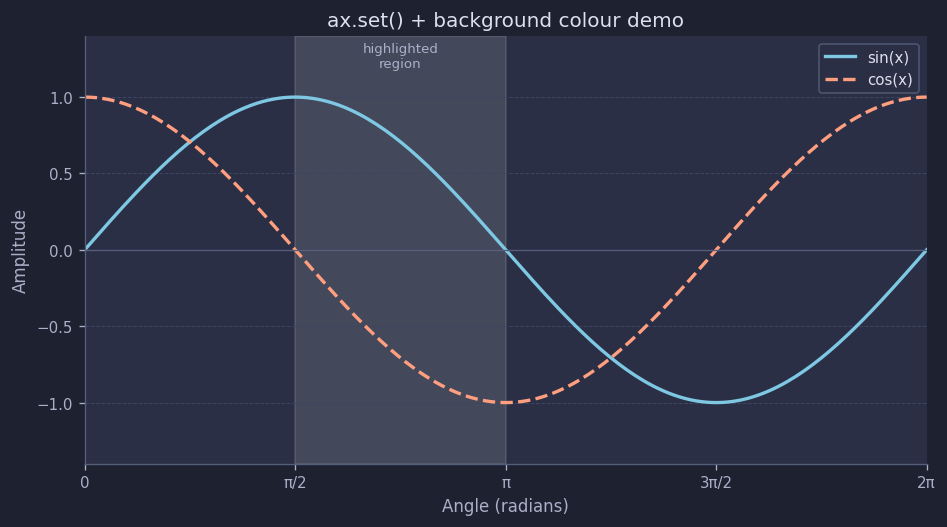

In [ ]:
x = np.linspace(0, 2 * np.pi, 200)

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=120)

fig.patch.set_facecolor('#1e2130')

ax.plot(x, np.sin(x), color='#7ec8e3', lw=2,          label='sin(x)')
ax.plot(x, np.cos(x), color='#ff9f7f', lw=2, ls='--', label='cos(x)')

ax.set(
    title = 'ax.set() + background colour demo',
    xlabel = 'Angle (radians)',
    ylabel = 'Amplitude',
    xlim = (0, 2 * np.pi),
    ylim = (-1.4, 1.4),
    xticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    xticklabels = ['0', 'π/2', 'π', '3π/2', '2π'],
    facecolor = '#2a2f45',   # axes background colour (inside the spines)
)

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_color('#555e7b')
ax.tick_params(colors='#aab0c8', labelsize=9)
ax.xaxis.label.set_color('#aab0c8')
ax.yaxis.label.set_color('#aab0c8')
ax.title.set_color('#dde1ef')
ax.grid(axis='y', color='#3d4460', linewidth=0.6, linestyle='--')

ax.axhline(0, color='#555e7b', lw=0.8)
ax.axvspan(np.pi/2, np.pi, alpha=0.12, color='white')
ax.text(np.pi * 0.75, 1.2, 'highlighted\nregion',
        color='#aab0c8', fontsize=8, ha='center')

legend = ax.legend(frameon=True, fontsize=9, loc='upper right')
legend.get_frame().set_facecolor('#2a2f45')
legend.get_frame().set_edgecolor('#555e7b')
for text in legend.get_texts():
    text.set_color('#dde1ef')

fig.tight_layout()
plt.show()